# Zara sales dataset analysis

## Importing library and csv file

In [248]:
import pandas as pd

df = pd.read_csv('/Users/remyfernando/Desktop/data portofolio/zara.csv', delimiter = ';') # File uses ';' as delimiter

## Initial Data Inspection and Cleaning

In [251]:
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


### Columns Description (From Kaggle)

- **Product ID**: Unique identifier for each product.
- **Product Position**: The position of the product in the catalog or store layout.
- **Promotion**: Indicator of whether the product is currently on promotion or not.
- **Product Category**: The category of the product, such as clothing, accessories, shoes, etc.
- **Seasonal**: Indicator of whether the product is part of a specific seasonal collection.
- **Sales Volume**: The quantity of products sold.
- **Brand**: Brand of the product.
- **URL**: Product URL (e.g., if the product is sold online).
- **SKU**: Stock Keeping Unit, a unique code used to identify items available for sale.
- **Name**: Name of the product.
- **Description**: Description of the product.
- **Price**: Price of the product.
- **Currency**: Currency of the product price.
- **Scraped_at**: The time when the data was scraped (e.g., in web scraping process).
- **Terms**: Terms or conditions of the product.
- **Section**: Section or category where the product is sold in the store (e.g., women's clothing, men's clothing, children's clothing, etc.).


In [254]:
pd.set_option('display.max_rows', None)

In [256]:
df.shape

(252, 16)

In [258]:
df.info() # Checking data types and potential null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Product Category  252 non-null    object 
 4   Seasonal          252 non-null    object 
 5   Sales Volume      252 non-null    int64  
 6   brand             252 non-null    object 
 7   url               252 non-null    object 
 8   sku               252 non-null    object 
 9   name              251 non-null    object 
 10  description       250 non-null    object 
 11  price             252 non-null    float64
 12  currency          252 non-null    object 
 13  scraped_at        252 non-null    object 
 14  terms             252 non-null    object 
 15  section           252 non-null    object 
dtypes: float64(1), int64(2), object(13)
memory u

In [260]:
df.isnull().sum() # Counting missing values

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
sku                 0
name                1
description         2
price               0
currency            0
scraped_at          0
terms               0
section             0
dtype: int64

In [262]:
df[df.isnull().any(axis = 1)] # Identifying rows with missing values

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
60,151925,End-cap,Yes,Clothing,Yes,2179,Zara,https://www.zara.com/us/en/vintage-effect-leat...,320774184-800-97,VINTAGE EFFECT LEATHER BOMBER JACKET,NaN,299.0,USD,2024-02-19T08:50:43.543555,jackets,MAN
72,173576,End-cap,Yes,Clothing,No,1838,Zara,https://www.zara.com/us/en/-p04310461.html,336378923-700-2,NaN,NaN,129.0,USD,2024-02-19T08:50:54.476057,jackets,MAN


Missing values in the 'name' and 'description' columns could not be retrieved using the product ID or URL. These rows will be kept, as the analysis depends on grouping data from other columns.

In [265]:
df.duplicated().sum() # Checking duplicates

0

In [267]:
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


## Looking at the terms and product category columns

In [270]:
# Values in the terms column
print('terms disticnt items :',df['terms'].unique().tolist())
print('product category distinct items:', df['Product Category'].unique().tolist())

terms disticnt items : ['jackets', 'shoes', 'sweaters', 'jeans', 't-shirts']
product category distinct items: ['Clothing']


In [272]:
# Replaceing product_category values with terms's
df['Product Category'] = df['terms']

#Dropping terms's column
df = df.drop(columns =['terms'])

## Saving cleaned table in csv file

In [278]:
df.to_csv('/Users/remyfernando/Desktop/data portofolio/cleaned_zara.csv')

### Column adjustments
- The only value in `Product Category` was **Clothing**.
- The `Terms` column contained more detailed category information (e.g., jackets, trousers).
- Therefore, the `Terms` column was **renamed to `Category`** for clarity.


### df is now saved without terms

In [189]:
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,section
0,185102,Aisle,No,jackets,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,MAN
1,188771,Aisle,No,jackets,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,MAN
2,180176,End-cap,Yes,jackets,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,MAN
3,112917,Aisle,Yes,jackets,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,MAN
4,192936,End-cap,No,jackets,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,MAN


In [142]:
### descriptive 

In [178]:

df[['Sales Volume', 'price']].describe()


,Sales Volume,price
count,252.000000,252.000000
mean,1823.702381,86.252540
std,697.703748,52.083205
min,529.000000,7.990000
25%,1243.000000,49.900000
50%,1839.500000,79.900000
75%,2398.750000,109.000000
max,2989.000000,439.000000


### Summary

- **252 product ID entries**
- **2 rows** with missing `name` which were kept, as analysis relies on grouping data from other columns
- **No duplicates** in `product ID`, but some **duplicate names** were found in the dataset. These duplicates are expected since product names can appear multiple times with different IDs.
- SQL analysis confirmed that duplicate names do not necessarily indicate duplicate products, as each product has a unique ID.
(See SQL file)

# EDA

In [148]:
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,name,description,price,currency,section
0,185102,Aisle,No,jackets,No,2823,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,MAN
1,188771,Aisle,No,jackets,No,654,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,MAN
2,180176,End-cap,Yes,jackets,Yes,2220,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,MAN
3,112917,Aisle,Yes,jackets,Yes,1568,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,MAN
4,192936,End-cap,No,jackets,Yes,2942,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,MAN


### Dropping columns which won't be used in the analysis
- `brand` value is only Zara
- `url`, `sku`, `description` not useful for analysis
- `scraped_at` timestamp almost the same for all entries, so not useful
- `currency` is USD for the whole dataset

In [180]:
df_trimmed = df.drop(['brand','url','sku','scraped_at','description','currency'], axis = 1).copy()

In [191]:
df_trimmed.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,name,price,section
0,185102,Aisle,No,jackets,No,2823,BASIC PUFFER JACKET,19.99,MAN
1,188771,Aisle,No,jackets,No,654,TUXEDO JACKET,169.00,MAN
2,180176,End-cap,Yes,jackets,Yes,2220,SLIM FIT SUIT JACKET,129.00,MAN
3,112917,Aisle,Yes,jackets,Yes,1568,STRETCH SUIT JACKET,129.00,MAN
4,192936,End-cap,No,jackets,Yes,2942,DOUBLE FACED JACKET,139.00,MAN


## descriptive stats

In [356]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [202]:
df_trimmed[['Sales Volume', 'price']].describe()

,Sales Volume,price
count,252.000000,252.000000
mean,1823.702381,86.252540
std,697.703748,52.083205
min,529.000000,7.990000
25%,1243.000000,49.900000
50%,1839.500000,79.900000
75%,2398.750000,109.000000
max,2989.000000,439.000000


<Axes: ylabel='Sales Volume'>

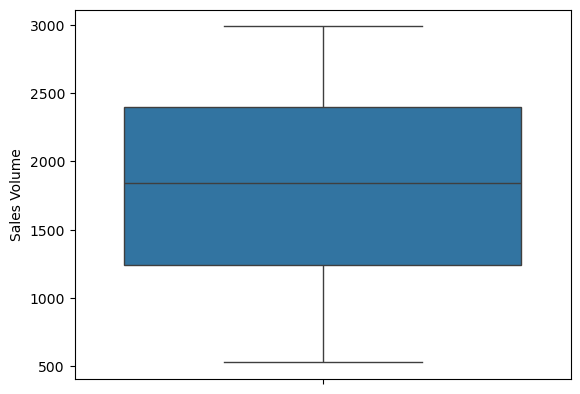

In [204]:
sns.boxplot(data = df_trimmed['Sales Volume'])

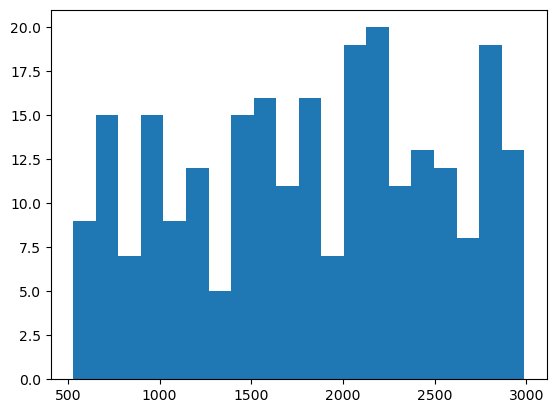

In [210]:
plt.hist(df_trimmed['Sales Volume'], bins = 20)
plt.show()

### Data distribution for sales volume

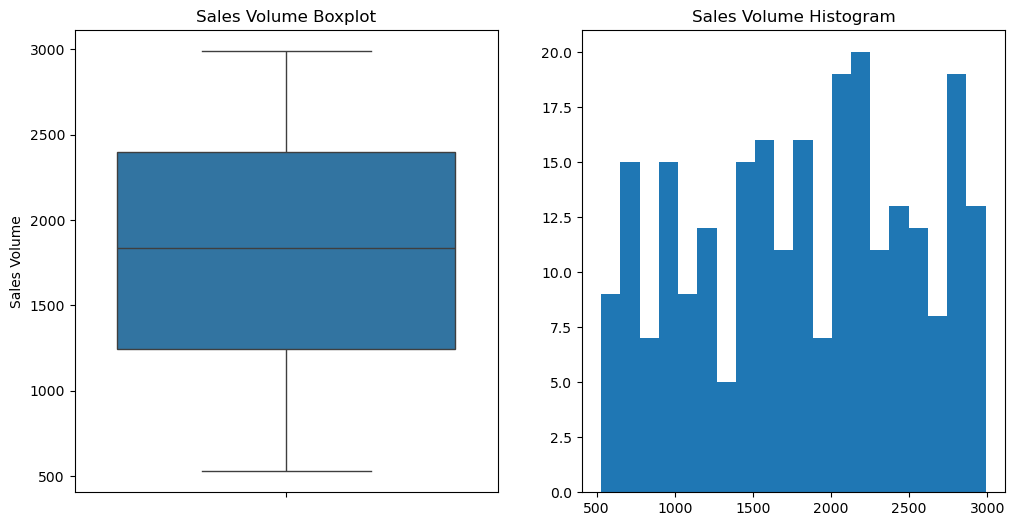

In [218]:

fig, axes = plt.subplots(1,2, figsize =(12,6))

# Seaborn boxplot for sales volume
sns.boxplot(data = df_trimmed['Sales Volume'], ax = axes[0])
axes[0].set_title('Sales Volume Boxplot')

# Matplotlib histogram  for Sales Volume
axes[1].hist(df_trimmed['Sales Volume'], bins = 20)
axes[1].set_title('Sales Volume Histogram')

plt.show()

### Data distribution for price

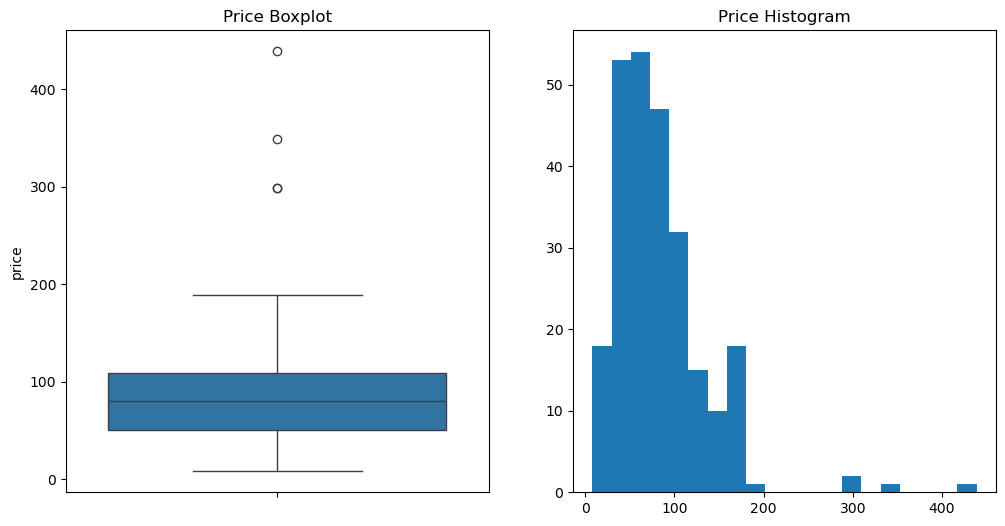

In [244]:
fig, axes = plt.subplots(1,2, figsize =(12,6))

# Seaborn boxplot for sales volume
sns.boxplot(data = df_trimmed['price'], ax = axes[0])
axes[0].set_title('Price Boxplot')

# Matplotlib histogram  for Sales Volume
axes[1].hist(df_trimmed['price'], bins = 20)
axes[1].set_title('Price Histogram')

plt.show()

### Price and Sales Volume Distribution

There is nothing to worry about with the **Sales Volume** distribution, but for **Prices**, there are several outliers. However, the bulk of the price distribution lies between **20** and **150**. 

I will not be doing much with the outliers, as they represent the prices of certain items, which are part of the dataset.


## Exploring main correlations

In [292]:
df_trimmed.groupby('section').count()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,name,price
section,,,,,,,,
MAN,218,218,218,218,218,218,217,218
WOMAN,34,34,34,34,34,34,34,34


In [314]:
df_trimmed[df_trimmed['Product Position'] == 'Aisle'].groupby('Product Category').size()#.reset_index(name='count')

Product Category
jackets     54
jeans        2
shoes       13
sweaters    12
t-shirts    16
dtype: int64

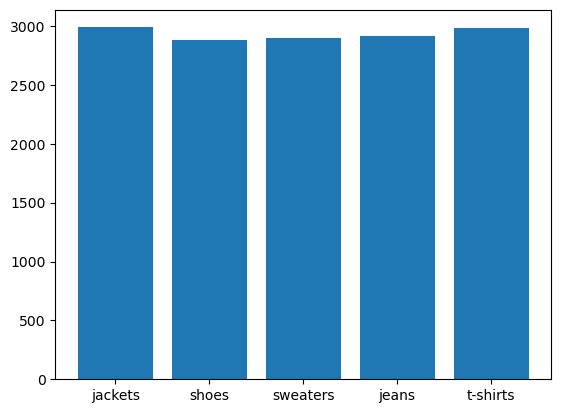

In [340]:
products = df_trimmed['Product Category']
sales = df_trimmed['Sales Volume']
plt.bar(products,sales)



#plt.bar(filtered['Product Category'], filtered['Sales Volume'], color='skyblue')

plt.show()

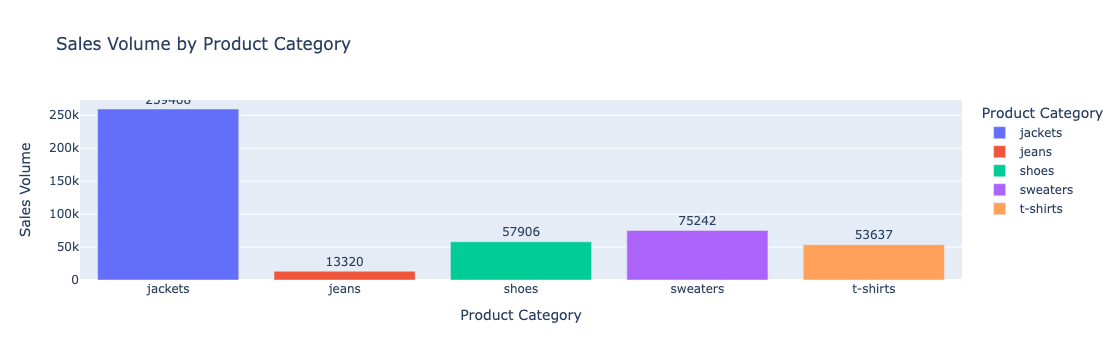

In [370]:
data = df_trimmed.groupby('Product Category')['Sales Volume'].sum().reset_index() # Reset_index returns it to a DataFrame(for plotting barchart)

fig = px.bar(
    data_frame = data,
    x = 'Product Category',
    y = 'Sales Volume',
    color = 'Product Category',
    text = 'Sales Volume',
    title='Sales Volume by Product Category'
)
fig.update_traces(textposition='outside')

fig.show()
#data.plot(kind = 'bar')

#plt.show()